In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.data_utils import MoonsDataHelper
import warnings
from utils.evaluation_utils import EvaluationHelper
from utils.neural_net_utils import NeuralNetHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [2]:
x_train, x_test, y_train, y_test = MoonsDataHelper.load_dataset()
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1600, 2), (400, 2), (1600,), (400,))

In [3]:
x_train.head()

,Feature_1,Feature_2
1860,1.216889,-0.627630
353,1.216012,-0.401308
1333,-0.617450,1.005901
905,1.625030,-0.216752
1289,0.798015,0.056454


In [4]:
y_train.head()

1860    1
353     1
1333    0
905     1
1289    0
Name: Class_1, dtype: int64

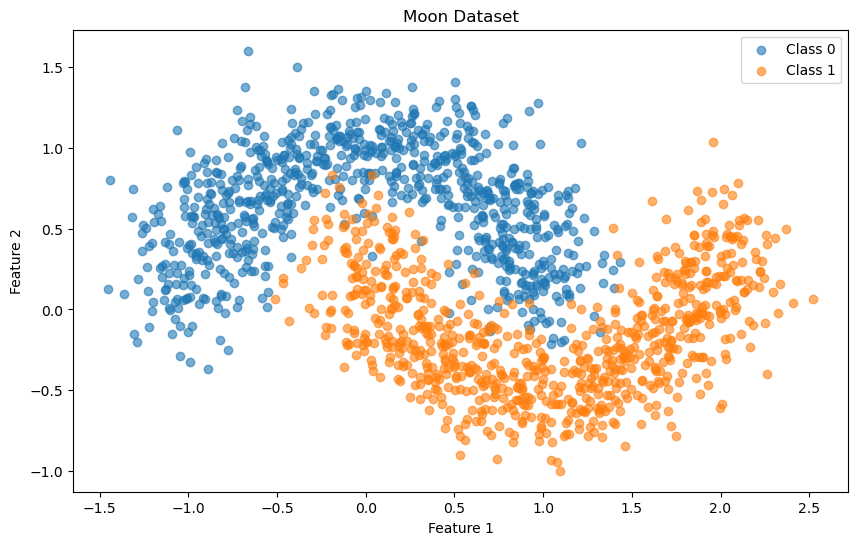

In [5]:
MoonsDataHelper.plot_moons(x_train, y_train)

## Model Training

In [6]:
x_train = np.array(x_train)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [7]:
def relu(input):
    return np.maximum(0, input)

def sigmoid(input):
    return 1 / (1 + np.exp(-input))

class Layer:
    def __init__(self, weights, biases):
        self.weights = weights
        self.biases = biases
    
    def forward(self, input):
        dot_product = np.dot(input, self.weights)
        return dot_product + self.biases

class ReluLayer(Layer):
    def __init__(self, weights, biases):
        super().__init__(weights, biases)
    
    def forward(self, input):
        result = super().forward(input)
        return relu(result)

class SigmoidLayer(Layer):
    def __init__(self, weights, biases):
        super().__init__(weights, biases)
    
    def forward(self, input):
        result = super().forward(input)
        return sigmoid(result)

In [8]:
def initialize_layers(input_size, hidden1_size, hidden2_size, output_size):
    hidden1_weights = np.random.normal(0, np.sqrt(2.0 / input_size), size=(input_size, hidden1_size))
    hidden1_biases = np.zeros(shape=(hidden1_size,))
    hidden1_layer = ReluLayer(hidden1_weights, hidden1_biases)

    hidden2_weights = np.random.normal(0, np.sqrt(2.0 / hidden1_size), size=(hidden1_size, hidden2_size))
    hidden2_biases = np.zeros(shape=(hidden2_size,))
    hidden2_layer = ReluLayer(hidden2_weights, hidden2_biases)

    output_weights = np.random.normal(0, np.sqrt(2.0 / hidden2_size), size=(hidden2_size, output_size))
    output_biases = np.zeros(shape=(output_size,))
    output_layer = SigmoidLayer(output_weights, output_biases)
    
    return hidden1_layer, hidden2_layer, output_layer

In [9]:
hidden1_layer, hidden2_layer, output_layer = initialize_layers(input_size=2, hidden1_size=10, hidden2_size=5, output_size=1)

In [10]:
def forward(x):
    hidden1_output = hidden1_layer.forward(x)
    hidden2_output = hidden2_layer.forward(hidden1_output)
    output = output_layer.forward(hidden2_output)
    return hidden1_output, hidden2_output, output

In [11]:
def compute_loss(y_true, prob):
    epsilon = 1e-15
    prob = np.clip(prob, epsilon, 1 - epsilon)
    loss = -(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))
    return loss

In [12]:
def clip_grad(grad, clip_value=1.0):
    norm = np.linalg.norm(grad)
    if norm > clip_value:
        grad = grad * (clip_value / norm)
    return grad

def backward(x, hidden1_output, hidden2_output, y_pred, y_true, learning_rate=0.01):
    output_error = y_pred - y_true
    output_weight_grad = np.outer(hidden2_output, output_error)
    output_bias_grad = output_error
    
    hidden2_error = np.dot(output_layer.weights, output_error) * (hidden2_output > 0)
    hidden2_weight_grad = np.outer(hidden1_output, hidden2_error)
    hidden2_bias_grad = hidden2_error
    
    hidden1_error = np.dot(hidden2_layer.weights, hidden2_error) * (hidden1_output > 0)
    hidden1_weight_grad = np.outer(x, hidden1_error)
    hidden1_bias_grad = hidden1_error
    
    output_weight_grad = clip_grad(output_weight_grad)
    output_bias_grad = clip_grad(output_bias_grad)
    hidden2_weight_grad = clip_grad(hidden2_weight_grad)
    hidden2_bias_grad = clip_grad(hidden2_bias_grad)
    hidden1_weight_grad = clip_grad(hidden1_weight_grad)
    hidden1_bias_grad = clip_grad(hidden1_bias_grad)
    
    output_layer.weights -= learning_rate * output_weight_grad
    output_layer.biases -= learning_rate * output_bias_grad
    hidden2_layer.weights -= learning_rate * hidden2_weight_grad
    hidden2_layer.biases -= learning_rate * hidden2_bias_grad
    hidden1_layer.weights -= learning_rate * hidden1_weight_grad
    hidden1_layer.biases -= learning_rate * hidden1_bias_grad    

In [13]:
epochs = 500
epoch_losses = []

learning_rate = 0.001

for epoch in range(epochs):
    total_loss = 0
    
    for i in range(len(x_train)):
        x = x_train[i]
        y_true = y_train[i]

        hidden1_output, hidden2_output, y_pred = forward(x)

        loss = compute_loss(y_true, y_pred[0])
    
        total_loss += loss

        backward(x, hidden1_output, hidden2_output, y_pred, y_true, learning_rate)

    avg_loss = total_loss / len(x_train)
        
    epoch_losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch: {epoch + 1}/{epochs} | Avg. Loss: {avg_loss:.6f}")

Epoch: 10/500 | Avg. Loss: 0.299982
Epoch: 20/500 | Avg. Loss: 0.288414
Epoch: 30/500 | Avg. Loss: 0.282308
Epoch: 40/500 | Avg. Loss: 0.279912
Epoch: 50/500 | Avg. Loss: 0.281350
Epoch: 60/500 | Avg. Loss: 0.284441
Epoch: 70/500 | Avg. Loss: 0.286965
Epoch: 80/500 | Avg. Loss: 0.288748
Epoch: 90/500 | Avg. Loss: 0.289662
Epoch: 100/500 | Avg. Loss: 0.289761
Epoch: 110/500 | Avg. Loss: 0.288756
Epoch: 120/500 | Avg. Loss: 0.286237
Epoch: 130/500 | Avg. Loss: 0.282027
Epoch: 140/500 | Avg. Loss: 0.275642
Epoch: 150/500 | Avg. Loss: 0.266942
Epoch: 160/500 | Avg. Loss: 0.254390
Epoch: 170/500 | Avg. Loss: 0.225509
Epoch: 180/500 | Avg. Loss: 0.211579
Epoch: 190/500 | Avg. Loss: 0.198337
Epoch: 200/500 | Avg. Loss: 0.185121
Epoch: 210/500 | Avg. Loss: 0.171597
Epoch: 220/500 | Avg. Loss: 0.157748
Epoch: 230/500 | Avg. Loss: 0.144238
Epoch: 240/500 | Avg. Loss: 0.131689
Epoch: 250/500 | Avg. Loss: 0.120985
Epoch: 260/500 | Avg. Loss: 0.110755
Epoch: 270/500 | Avg. Loss: 0.100803
Epoch: 280

In [14]:
def predict(x):
    _, _, y_pred = forward(x)
    return (y_pred[0] > 0.5).astype(int), y_pred[0]

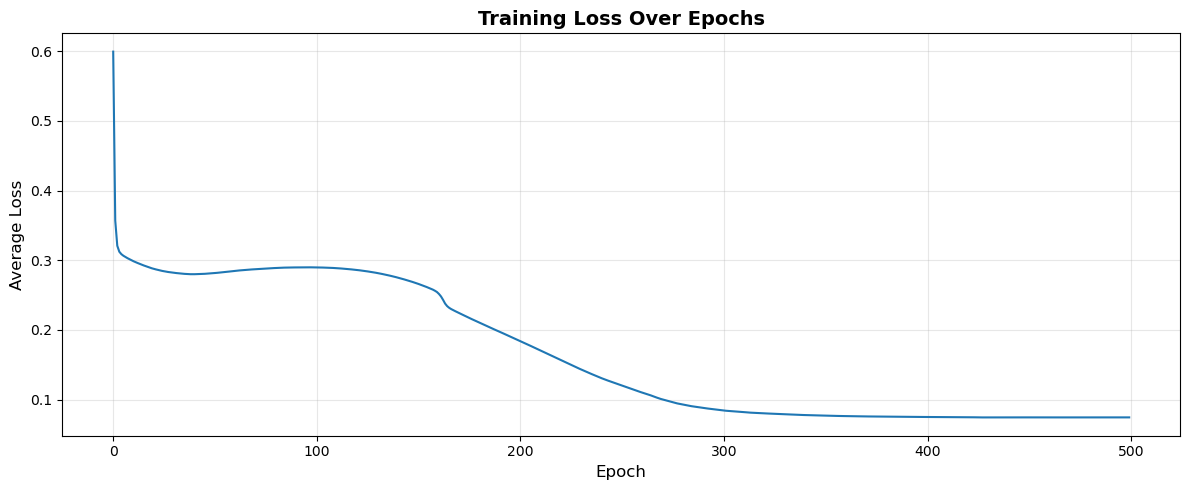

Initial loss: 0.599504
Final loss: 0.074388
Loss reduction: 87.59%


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(epoch_losses, linewidth=1.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Average Loss", fontsize=12)
ax.set_title("Training Loss Over Epochs", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {epoch_losses[0]:.6f}")
print(f"Final loss: {epoch_losses[-1]:.6f}")
print(f"Loss reduction: {(epoch_losses[0] - epoch_losses[-1])/epoch_losses[0]*100:.2f}%")

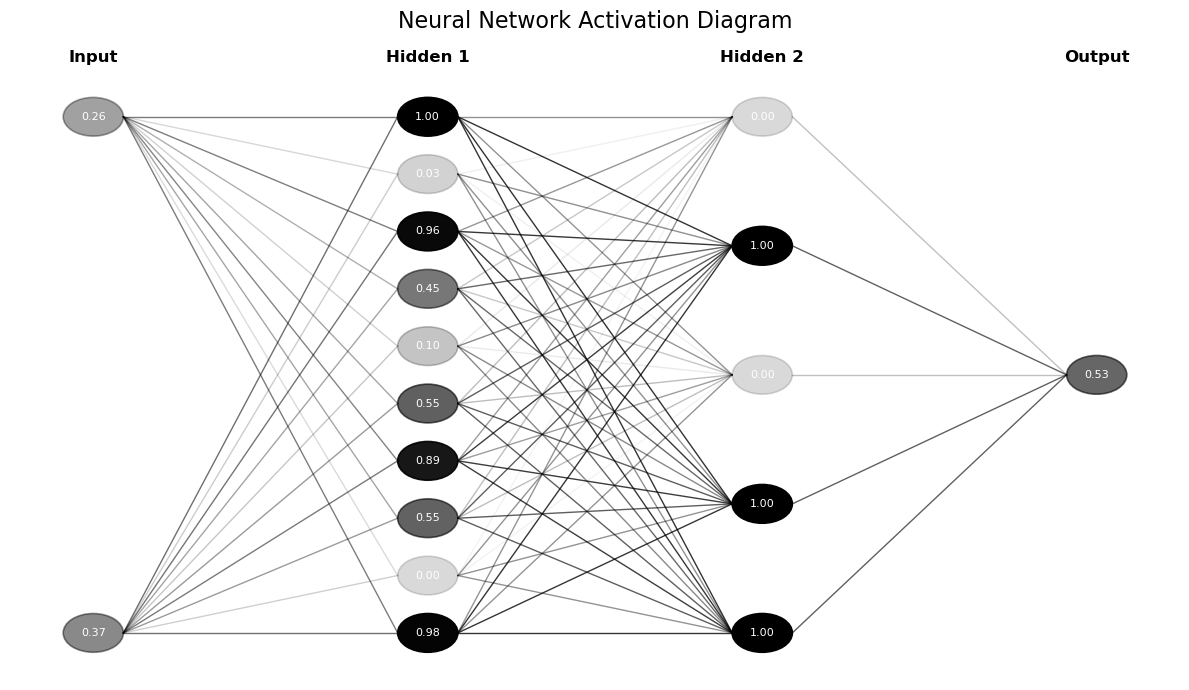

In [22]:
random_sample = x_train[np.random.randint(len(x_train))]

hidden1_output, hidden2_output, final_output = forward(random_sample)
NeuralNetHelper.plot_activations(random_sample, hidden1_output, hidden2_output, final_output)

## Model Evaluation

In [17]:
predictions = []
probabilities = []

for x in x_test:
    prediction, prob = predict(x)
    predictions.append(prediction)
    probabilities.append(prob)

predictions = np.array(predictions)
probabilities = np.array(probabilities)

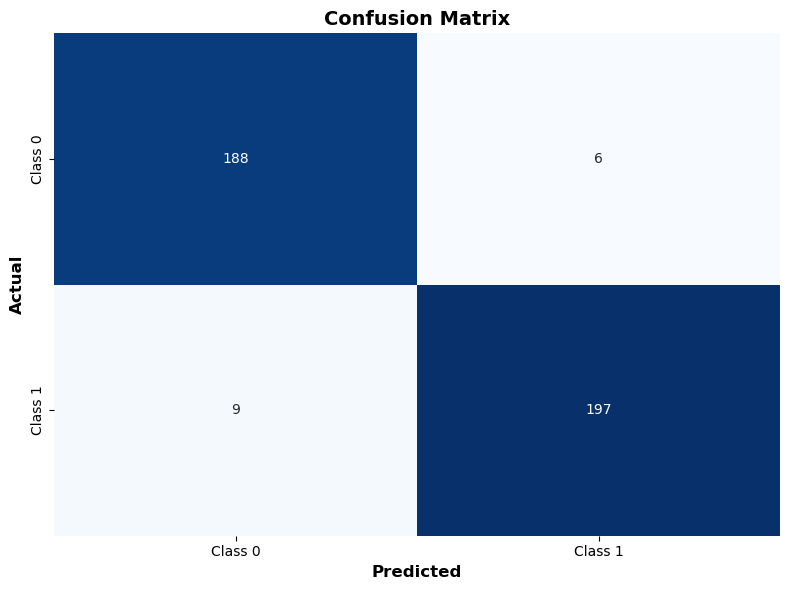

True Negatives: 188
False Positives: 6
False Negatives: 9
True Positives: 197

Sensitivity (Recall): 0.9563
Specificity: 0.9691
Precision: 0.9704
Accuracy: 0.9625
F1 Score: 0.9633


In [18]:
EvaluationHelper.plot_confusion_matrix(y_test, predictions, class_names=["Class 0", "Class 1"])

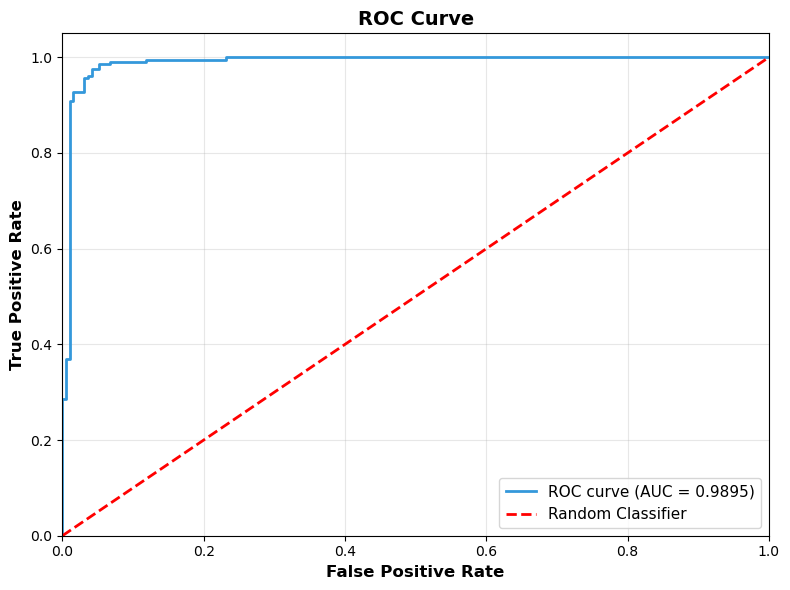

Area Under the Curve (AUC): 0.9895


In [19]:
EvaluationHelper.plot_roc_curve(y_test, probabilities)


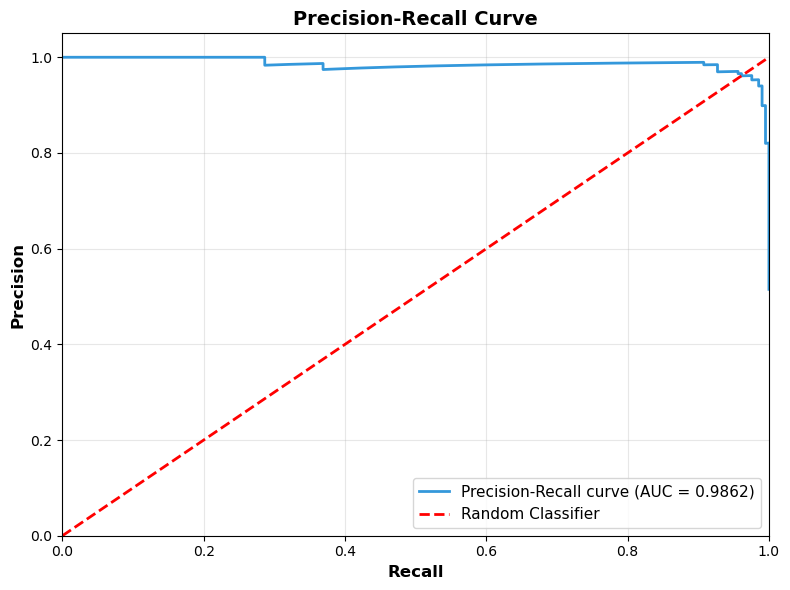

Area Under the Curve (AUC): 0.9862


In [20]:
EvaluationHelper.plot_precision_recall_curve(y_test, probabilities)

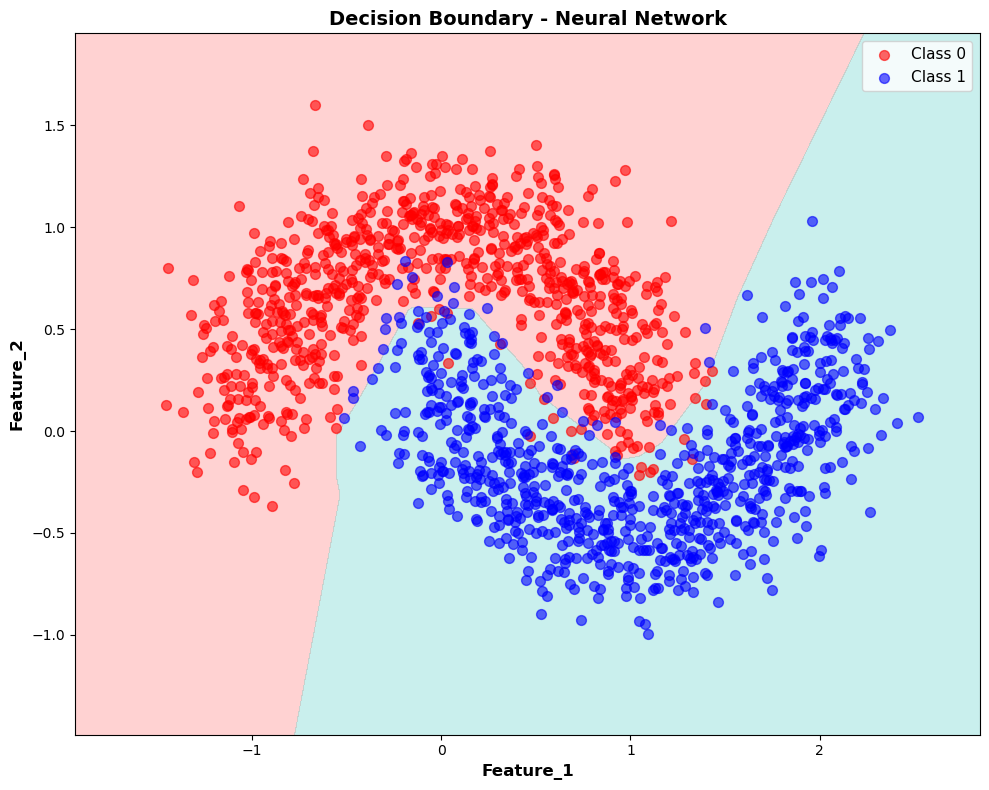

In [21]:
h = 0.02
x_min, x_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
y_min, y_max = x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = np.array([predict(np.array([xx[i, j], yy[i, j]]))[1]
              for i in range(xx.shape[0]) for j in range(xx.shape[1])])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, alpha=0.3, levels=[0, 0.5, 1], colors=['#FF6B6B', '#4ECDC4'])
ax.scatter(x_train[y_train == 0, 0], x_train[y_train == 0, 1], 
           c='red', marker='o', label='Class 0', alpha=0.6, s=50)
ax.scatter(x_train[y_train == 1, 0], x_train[y_train == 1, 1], 
           c='blue', marker='o', label='Class 1', alpha=0.6, s=50)
ax.set_xlabel('Feature_1', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature_2', fontsize=12, fontweight='bold')
ax.set_title('Decision Boundary - Neural Network', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()